In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import pickle

import utils
import paths as p

# pull bg_time_drawn from behavior data and add to trials

get behavior training log

In [3]:
behavior_data_dir = '/Users/rebekahzhang/data/behavior_data/exp2/c567'

In [6]:
behavior_log = pd.read_csv(os.path.join(behavior_data_dir, 'sessions_training.csv'), index_col=0)
behavior_log['datetime'] = pd.to_datetime(behavior_log['date'] + ' ' + behavior_log['time'].str.replace('-', ':'), 
                                          format='%Y-%m-%d %H:%M:%S')

match neural log with behavior log by mouse and datetime to get dir name

In [ ]:
sessions_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_vetted.csv'), index_col=0)

# Ensure 'datetime' column in sessions_vetted is datetime type for merging
sessions_vetted['datetime'] = pd.to_datetime(sessions_vetted['datetime'])

# Merge sessions_vetted with behavior_log on 'mouse' and 'datetime'
sessions_vetted = sessions_vetted.merge(
    behavior_log[['mouse', 'datetime', 'dir']],
    how='left',
    left_on=['mouse', 'datetime'],
    right_on=['mouse', 'datetime']
)

load behavior trials and get bg_drawn to add to neural trials

In [9]:
for _, session_info in sessions_vetted.iterrows():
    dir = session_info['dir']
    trials_behavior = pd.read_csv(os.path.join(behavior_data_dir, dir, f'trials_analyzed_{dir}.csv'), index_col=0)

    pickle_name = session_info['id'] + ".pkl"
    pickle_path = os.path.join(p.PICKLE_DIR, pickle_name)
    with open(pickle_path, 'rb') as f:
        session_data = pickle.load(f)

    trials = session_data['trials']
    trials = trials.merge(
        trials_behavior[['session_trial_num', 'bg_drawn']],
        left_on='trial_id',
        right_on='session_trial_num',
        how='left'
        )
    trials = trials.drop(columns=['session_trial_num'])

    session_data['trials'] = trials

    with open(os.path.join(p.PICKLE_DIR, pickle_name), 'wb') as f:
        pickle.dump(session_data, f)

# plot bg_drawn with respect to tw

In [12]:
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0).sort_values('unit_id')
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id='RZ034_2024-07-13_str', unit_id=112)

In [13]:
trials

,subject,session_datetime,event_start_time,trial_id,event_end_time,trial_length,missed,rewarded,cue_on_time,cue_off_time,decision_time,background_length,wait_length,num_bg_repeat,consumption_length,bg_drawn
0,RZ034,2024-07-13 12:58:26,74.828046,0,80.510174,5.682128,False,False,0.008805,1.420995,2.682135,1.412189,1.261240,3,2.999993,0.9
1,RZ034,2024-07-13 12:58:26,80.510184,1,85.704686,5.194502,False,True,0.006601,1.109040,2.194500,1.102439,1.085460,1,3.000002,0.9
2,RZ034,2024-07-13 12:58:26,85.704686,2,91.300295,5.595609,False,False,0.006192,1.106494,2.595602,1.100302,1.489208,0,3.000007,1.1
3,RZ034,2024-07-13 12:58:26,91.300395,3,97.855592,6.555196,False,False,0.006306,1.940388,3.555176,1.934082,1.614788,3,3.000020,1.0
4,RZ034,2024-07-13 12:58:26,97.855692,4,105.117992,7.262300,False,False,0.006602,3.244288,4.262285,3.237686,1.018097,3,3.000015,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,RZ034,2024-07-13 12:58:26,2485.959386,323,2491.391572,5.432186,False,True,0.006888,1.002184,2.433679,0.995296,1.431595,0,2.998508,1.0
324,RZ034,2024-07-13 12:58:26,2491.393071,324,2496.711577,5.318505,False,True,0.007796,1.108505,2.322889,1.100709,1.214384,0,2.995617,1.1
325,RZ034,2024-07-13 12:58:26,2496.715979,325,2505.151536,8.435557,False,True,0.006704,1.005600,5.439264,0.998896,4.433764,0,2.996293,1.0
326,RZ034,2024-07-13 12:58:26,2505.155339,326,2512.251551,7.096211,False,True,0.006908,1.206215,4.092016,1.199308,2.885800,0,3.004196,1.2


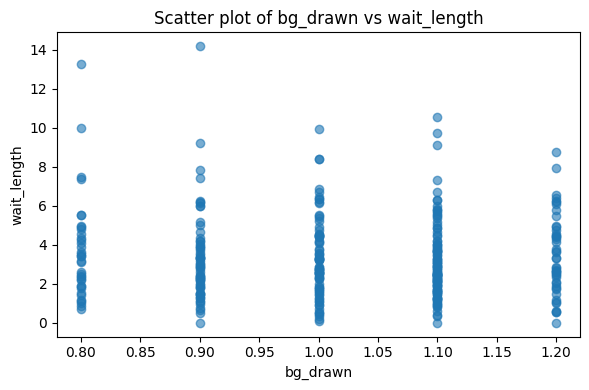

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(trials['bg_drawn'], trials['wait_length'], alpha=0.6)
plt.xlabel('bg_drawn')
plt.ylabel('wait_length')
plt.title('Scatter plot of bg_drawn vs wait_length')
plt.tight_layout()

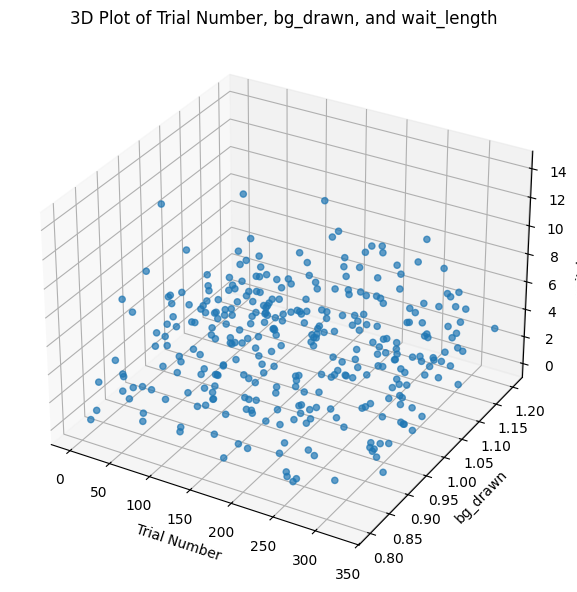

In [15]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trials.index, trials['bg_drawn'], trials['wait_length'], alpha=0.7)
ax.set_xlabel('Trial Number')
ax.set_ylabel('bg_drawn')
ax.set_zlabel('wait_length')
ax.set_title('3D Plot of Trial Number, bg_drawn, and wait_length')
plt.tight_layout()

In [16]:
import statsmodels.api as sm

# Prepare the data for regression: predict wait_length from bg_drawn
X = trials['bg_drawn']
y = trials['wait_length']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            wait_length   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4088
Date:                Mon, 23 Jun 2025   Prob (F-statistic):              0.523
Time:                        16:11:42   Log-Likelihood:                -713.12
No. Observations:                 328   AIC:                             1430.
Df Residuals:                     326   BIC:                             1438.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9506      0.998      3.960      0.0

In [ ]:
def plot_first_lick(events):
    # Filter for lick events
    lick_events = events[events['event_type'].isin(['lick_bg', 'lick_wait', 'lick_cons'])]

    # Find the first lick in each trial
    first_licks = lick_events.sort_values(['trial_id', 'event_start_trial_time']).groupby('trial_id').first()

    # Plot the distribution of the first lick times within trial
    plt.figure(figsize=(6, 4))
    plt.hist(first_licks['event_start_trial_time'], bins=200, color='skyblue', edgecolor='k')
    plt.xlabel('First lick time in trial (s)')
    plt.ylabel('Count')
    plt.title('Distribution of First Lick Time per Trial')
    plt.xlim(0, 15)
    plt.tight_layout()

In [ ]:
# # Filter trials that have at least two 'lick_bg' events
# lick_events = events[events['event_type'].isin(['lick_bg', 'lick_wait', 'lick_cons'])]
# trials_with_lick_bg = lick_bg_events['trial_id'].unique()

# # For these trials, get the second lick event (any type)
# second_licks = (
#     lick_events[lick_events['trial_id'].isin(trials_with_lick_bg)]
#     .sort_values(['trial_id', 'event_start_trial_time'])
#     .groupby('trial_id')
#     .nth(1)
# )

# # Plot the distribution of the second lick times within trial
# plt.figure(figsize=(6, 4))
# plt.hist(second_licks['event_start_trial_time'], bins=40, color='orange', edgecolor='k')
# plt.xlabel('Time in trial (s)')
# plt.ylabel('Count')
# plt.title('Distribution of Second Lick Time per Trial')
# plt.tight_layout()

In [ ]:
# Calculate the percentage of trials that had at least one 'lick_bg' event
lick_bg_trials = events[events['event_type'] == 'lick_bg']['trial_id'].nunique()
total_trials = events['trial_id'].nunique()
percent_lick_bg = 100 * lick_bg_trials / total_trials
print(f"% trials with lick_bg: {percent_lick_bg:.2f}%")

In [ ]:
plot_first_lick(events)

In [ ]:
session_id = 'RZ038_2024-07-19_str'
events, trials, units = utils.get_session_data(session_id)

In [ ]:
plot_first_lick(events)

In [ ]:
for idx, row in sessions_vetted.iterrows():
    session_id = row['id']
    # Load events for this session
    events_session = pd.read_csv(os.path.join(p.LOGS_DIR, f'{session_id}_events.csv'))
    # Filter for lick events
    lick_events = events_session[events_session['event_type'].isin(['lick_bg', 'lick_wait', 'lick_cons'])]
    # Find the first lick in each trial
    first_licks = lick_events.sort_values(['trial_id', 'event_start_trial_time']).groupby('trial_id').first()
    # Plot the distribution
    plt.figure(figsize=(6, 4))
    plt.hist(first_licks['event_start_trial_time'], bins=40, color='skyblue', edgecolor='k')
    plt.xlabel('First lick time in trial (s)')
    plt.ylabel('Count')
    plt.title(f'First Lick Distribution: {session_id}')
    plt.tight_layout()
    plt.show()